In [ ]:
!nvidia-smi

Mon Dec 22 18:23:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   39C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q segmentation-models-pytorch albumentations opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.1 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [ ]:
DATA_DIR = "/content/drive/MyDrive/data/cubicasa"

IMG_DIR = os.path.join(DATA_DIR, "images")
MASK_DIR = os.path.join(DATA_DIR, "masks")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 5
IMG_SIZE = 512
BATCH_SIZE = 8
EPOCHS = 50

In [ ]:
class CubiCasaDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        image = cv2.imread(os.path.join(self.image_dir, img_name))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(os.path.join(self.mask_dir, img_name), cv2.IMREAD_GRAYSCALE)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, mask.long()

In [ ]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
from sklearn.model_selection import train_test_split

all_images = sorted(os.listdir(IMG_DIR))
train_imgs, val_imgs = train_test_split(all_images, test_size=0.15, random_state=42)

def subset_copy(file_list, src_img, src_mask, dst):
    os.makedirs(dst + "/images", exist_ok=True)
    os.makedirs(dst + "/masks", exist_ok=True)
    for f in file_list:
        os.system(f"cp {src_img}/{f} {dst}/images/")
        os.system(f"cp {src_mask}/{f} {dst}/masks/")

subset_copy(train_imgs, IMG_DIR, MASK_DIR, "/content/train")
subset_copy(val_imgs, IMG_DIR, MASK_DIR, "/content/val")

In [ ]:
train_ds = CubiCasaDataset("/content/train/images", "/content/train/masks", train_transform)
val_ds   = CubiCasaDataset("/content/val/images", "/content/val/masks", val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=3,
    classes=NUM_CLASSES,
)

model = model.to(DEVICE)

In [ ]:
dice_loss = smp.losses.DiceLoss(mode="multiclass")
focal_loss = smp.losses.FocalLoss(mode="multiclass")

def loss_fn(preds, targets):
    return dice_loss(preds, targets) + focal_loss(preds, targets)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [ ]:
def train_epoch(loader, model):
    model.train()
    total_loss = 0
    total_iou = 0
    total_dice = 0

    for imgs, masks in tqdm(loader):
        imgs = imgs.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = loss_fn(outputs, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Metrics (no grad needed)
        with torch.no_grad():
            preds = torch.argmax(outputs, dim=1)

            tp, fp, fn, tn = smp.metrics.get_stats(
                preds,
                masks,
                mode="multiclass",
                num_classes=NUM_CLASSES
            )

            total_iou += smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()
            total_dice += smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro").item()

    avg_loss = total_loss / len(loader)
    avg_iou = total_iou / len(loader)
    avg_dice = total_dice / len(loader)

    return avg_loss, avg_iou, avg_dice

def val_epoch(loader, model):
    model.eval()
    total_iou = 0
    total_dice = 0

    with torch.no_grad():
        for imgs, masks in loader:
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            # REQUIRED in new SMP versions
            tp, fp, fn, tn = smp.metrics.get_stats(
                preds,
                masks,
                mode="multiclass",
                num_classes=NUM_CLASSES
            )

            iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
            dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")

            total_iou += iou.item()
            total_dice += dice.item()

    return total_iou / len(loader), total_dice / len(loader)


In [ ]:
best_iou = 0

for epoch in range(EPOCHS):
    train_loss, train_iou, train_dice = train_epoch(train_loader, model)
    val_iou, val_dice = val_epoch(val_loader, model)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss:.4f} | "
        f"Train IoU: {train_iou:.4f} | Train Dice: {train_dice:.4f} | "
        f"Val IoU: {val_iou:.4f} | Val Dice: {val_dice:.4f}"
    )

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "best_unetpp_cubicasa.pth")

100%|██████████| 169/169 [01:31<00:00,  1.85it/s]


Epoch [1/50] | Loss: 1.1695 | Train IoU: 0.5895 | Train Dice: 0.6994 | Val IoU: 0.8390 | Val Dice: 0.9124


100%|██████████| 169/169 [01:30<00:00,  1.88it/s]


Epoch [2/50] | Loss: 0.7253 | Train IoU: 0.8630 | Train Dice: 0.9264 | Val IoU: 0.8774 | Val Dice: 0.9347


100%|██████████| 169/169 [01:30<00:00,  1.86it/s]


...

Epoch [48/50] | Loss: 0.2087 | Train IoU: 0.9405 | Train Dice: 0.9693 | Val IoU: 0.9370 | Val Dice: 0.9674


100%|██████████| 169/169 [01:30<00:00,  1.86it/s]


Epoch [49/50] | Loss: 0.2045 | Train IoU: 0.9414 | Train Dice: 0.9698 | Val IoU: 0.9390 | Val Dice: 0.9685


100%|██████████| 169/169 [01:30<00:00,  1.86it/s]


Epoch [50/50] | Loss: 0.2029 | Train IoU: 0.9417 | Train Dice: 0.9700 | Val IoU: 0.9371 | Val Dice: 0.9675


In [ ]:
set(os.listdir("/content/train/images")) & set(os.listdir("/content/val/images"))

set()

Loading model...
Model loaded successfully!

Upload an image to predict:


Saving F1_scaled.png to F1_scaled.png

Predicting on: F1_scaled.png
Prediction shape: (512, 512)
Unique classes in prediction: [0 1 2 3]


/tmp/ipython-input-2193117809.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


Visualization saved to prediction_F1_scaled.png


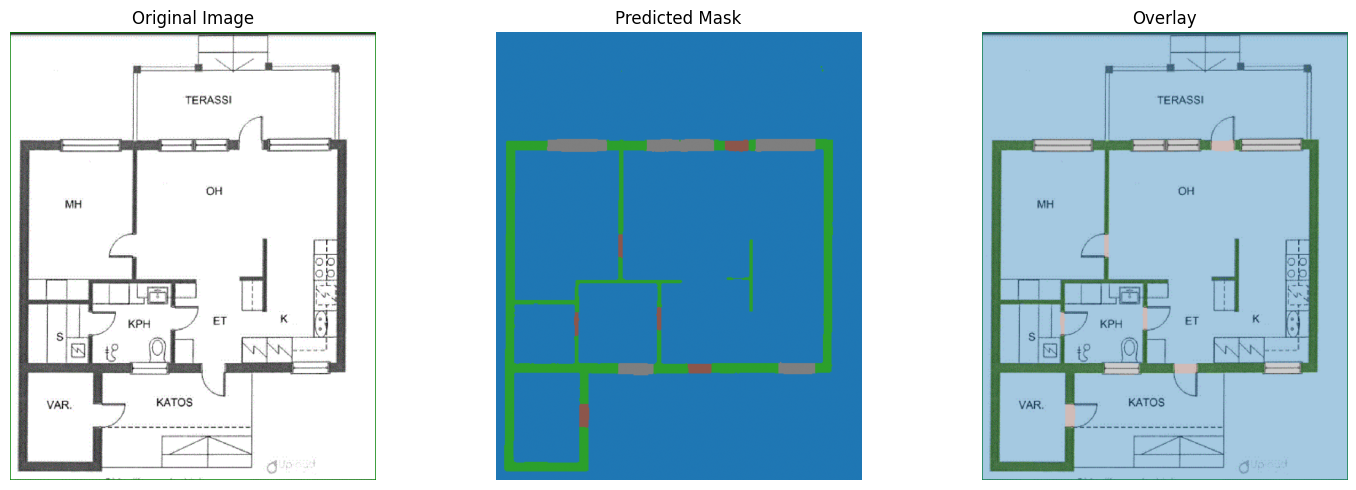

Prediction mask saved to mask_F1_scaled.png



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import cv2
import numpy as np
import torch
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

MODEL_PATH = "/content/drive/MyDrive/best_unetpp_cubicasa.pth"
IMG_SIZE = 512
NUM_CLASSES = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

inference_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

def load_model(model_path, num_classes):
    model = smp.UnetPlusPlus(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=num_classes,
    )

    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()

    return model

def predict_single_image(image_path, model, transform):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_image = image.copy()

    augmented = transform(image=image)
    image_tensor = augmented["image"].unsqueeze(0)

    image_tensor = image_tensor.to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)
        prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    return prediction, original_image

def predict_batch(image_paths, model, transform):
    predictions = []
    original_images = []

    for img_path in image_paths:
        pred, orig = predict_single_image(img_path, model, transform)
        predictions.append(pred)
        original_images.append(orig)

    return predictions, original_images

def visualize_prediction(image, prediction, num_classes, save_path=None):
    pred_resized = cv2.resize(
        prediction.astype(np.uint8),
        (image.shape[1], image.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    colors = plt.cm.get_cmap('tab10', num_classes)
    colored_mask = colors(pred_resized)[:, :, :3]
    colored_mask = (colored_mask * 255).astype(np.uint8)

    overlay = cv2.addWeighted(image, 0.6, colored_mask, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    axes[1].imshow(pred_resized, cmap='tab10', vmin=0, vmax=num_classes-1)
    axes[1].set_title("Predicted Mask")
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    axes[2].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Visualization saved to {save_path}")

    plt.show()

def save_prediction_mask(prediction, save_path):
    cv2.imwrite(save_path, prediction.astype(np.uint8))
    print(f"Prediction mask saved to {save_path}")

from google.colab import files
from io import BytesIO
from PIL import Image

print("Loading model...")
model = load_model(MODEL_PATH, NUM_CLASSES)
print("Model loaded successfully!")

print("\nUpload an image to predict:")
uploaded = files.upload()

for filename, data in uploaded.items():
    with open(filename, 'wb') as f:
        f.write(data)

    print(f"\nPredicting on: {filename}")

    prediction, original_image = predict_single_image(
        filename,
        model,
        inference_transform
    )

    print(f"Prediction shape: {prediction.shape}")
    print(f"Unique classes in prediction: {np.unique(prediction)}")

    visualize_prediction(
        original_image,
        prediction,
        NUM_CLASSES,
        save_path=f"prediction_{filename}"
    )

    save_prediction_mask(prediction, f"mask_{filename}")

print("\nDownloading generated predictions:")
for filename in uploaded.keys():
    pred_file = f"prediction_{filename}"
    mask_file = f"mask_{filename}"

    if os.path.exists(pred_file):
        files.download(pred_file)
    if os.path.exists(mask_file):
        files.download(mask_file)